In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [73]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [74]:
df.shape

(100000, 9)

In [75]:
df.isnull().any()
#df.isnull().values.any()
#we have no missing values

gender                 False
age                    False
hypertension           False
heart_disease          False
smoking_history        False
bmi                    False
HbA1c_level            False
blood_glucose_level    False
diabetes               False
dtype: bool

In [76]:
#lets count number of male and female
gender_count = df['gender']

In [77]:
gender_count.value_counts()

Female    58552
Male      41430
Other        18
Name: gender, dtype: int64

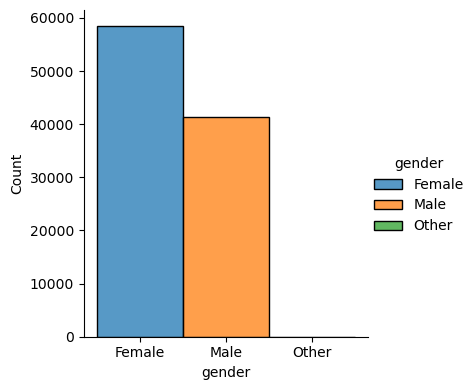

In [78]:
sns.FacetGrid(df,hue='gender',height=4).map(sns.histplot,'gender').add_legend()
plt.show()

In [79]:
#lets find number of male who have diabetes
dib_male = df[(df['diabetes']==1) & (df['gender']=='Male')]
dib_male['diabetes'].value_counts()

1    4039
Name: diabetes, dtype: int64

In [80]:
#number of male who dont have diabetes
no_dib_male = df[(df['diabetes']==0) & (df['gender']=='Male')]
no_dib_male['diabetes'].value_counts()

0    37391
Name: diabetes, dtype: int64

In [81]:
#number of female who have diabetes
dib_female = df[(df['diabetes']==1) & (df['gender']=='Female')]
dib_female['diabetes'].value_counts()

1    4461
Name: diabetes, dtype: int64

In [82]:
#number of female who dont have diabetes
no_dib_female = df[(df['diabetes']==0) & (df['gender']=='Female')]
no_dib_female['diabetes'].value_counts()

0    54091
Name: diabetes, dtype: int64

In [83]:
#number of other gender who have diabetes
no_dib_other = df[(df['diabetes']==1) & (df['gender']=='Other')]
no_dib_other['diabetes'].value_counts()

Series([], Name: diabetes, dtype: int64)

In [84]:
#number of other gender who dont have diabetes
dib_other = df[(df['diabetes']==0) & (df['gender']=='Other')]
dib_other['diabetes'].value_counts()

0    18
Name: diabetes, dtype: int64

Text(0, 0.5, 'Counts')

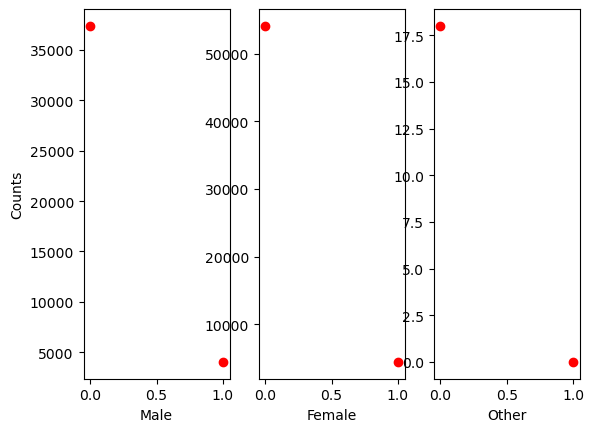

In [85]:
#https://stackoverflow.com/questions/65610752/set-multiple-xlabels-in-python
fig, (ax1, ax2,ax3) = plt.subplots(1,3)

ax1.plot([0,1], [37391,4039],'ro')
ax2.plot([0,1], [54091,4461], 'ro') 
ax3.plot([0,1],[18,0],'ro')

ax1.set_xlabel('Male')  
ax2.set_xlabel('Female')
ax3.set_xlabel('Other')
ax1.set_ylabel('Counts')


# Conclusions
- We have total of 100000 Data.
- From which 58552 are female, 41430 Male and 18 other.
- Out of 58552 Female, 4461 of them have diabetes.
- Out of 41430 Male, 4039 of them have diabetes.
- Out of 18 Other, 0 of them have diabetes.

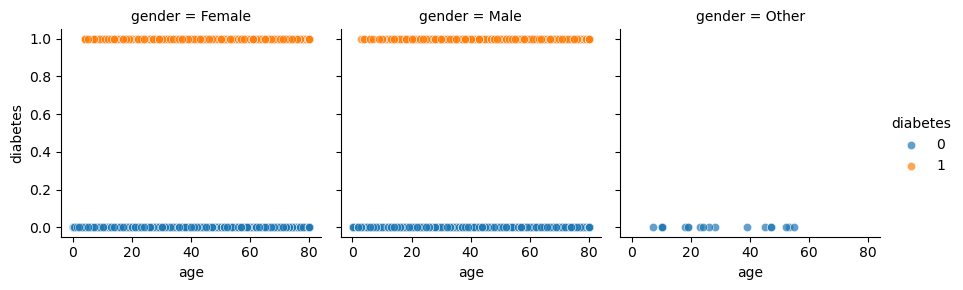

In [86]:
g = sns.FacetGrid(df, col="gender", hue="diabetes")
g.map(sns.scatterplot, "age",'diabetes', alpha=.7)
g.add_legend()

# Observations:
- We can say gender and age are not useful feature while predicting diabetes.
- This assumption is incorrect for Other gender, it may be because we have very less data for other gender.

In [87]:
df['age'].min()

0.08

In [88]:
df['age'].max()

80.0

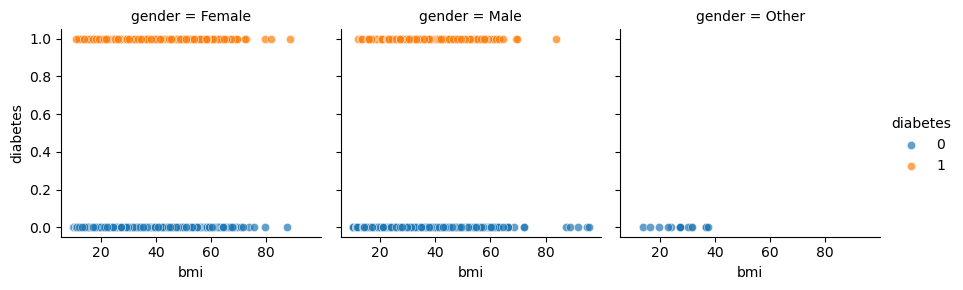

In [89]:
g = sns.FacetGrid(df, col="gender", hue="diabetes")
g.map(sns.scatterplot, "bmi",'diabetes', alpha=.7)
g.add_legend()

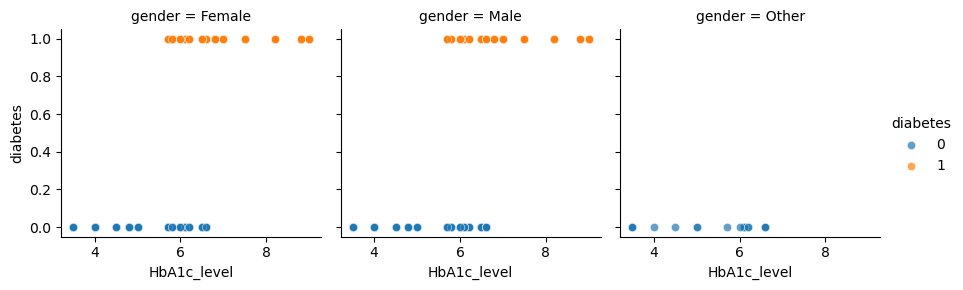

In [90]:
g = sns.FacetGrid(df, col="gender", hue="diabetes")
g.map(sns.scatterplot, "HbA1c_level",'diabetes', alpha=.7)
g.add_legend()

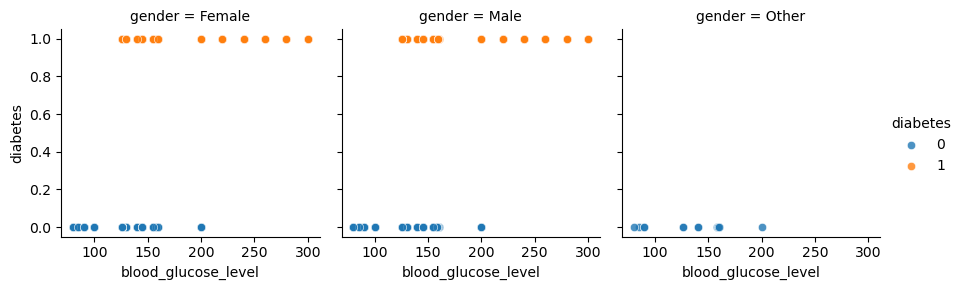

In [91]:
g = sns.FacetGrid(df, col="gender", hue="diabetes")
g.map(sns.scatterplot, "blood_glucose_level",'diabetes', alpha=.8)
g.add_legend()

# Observations: 
- We can say as 'HbA1c_level' increases chance of getting diabetes also increses.
- HbA1c_level is useful feature.

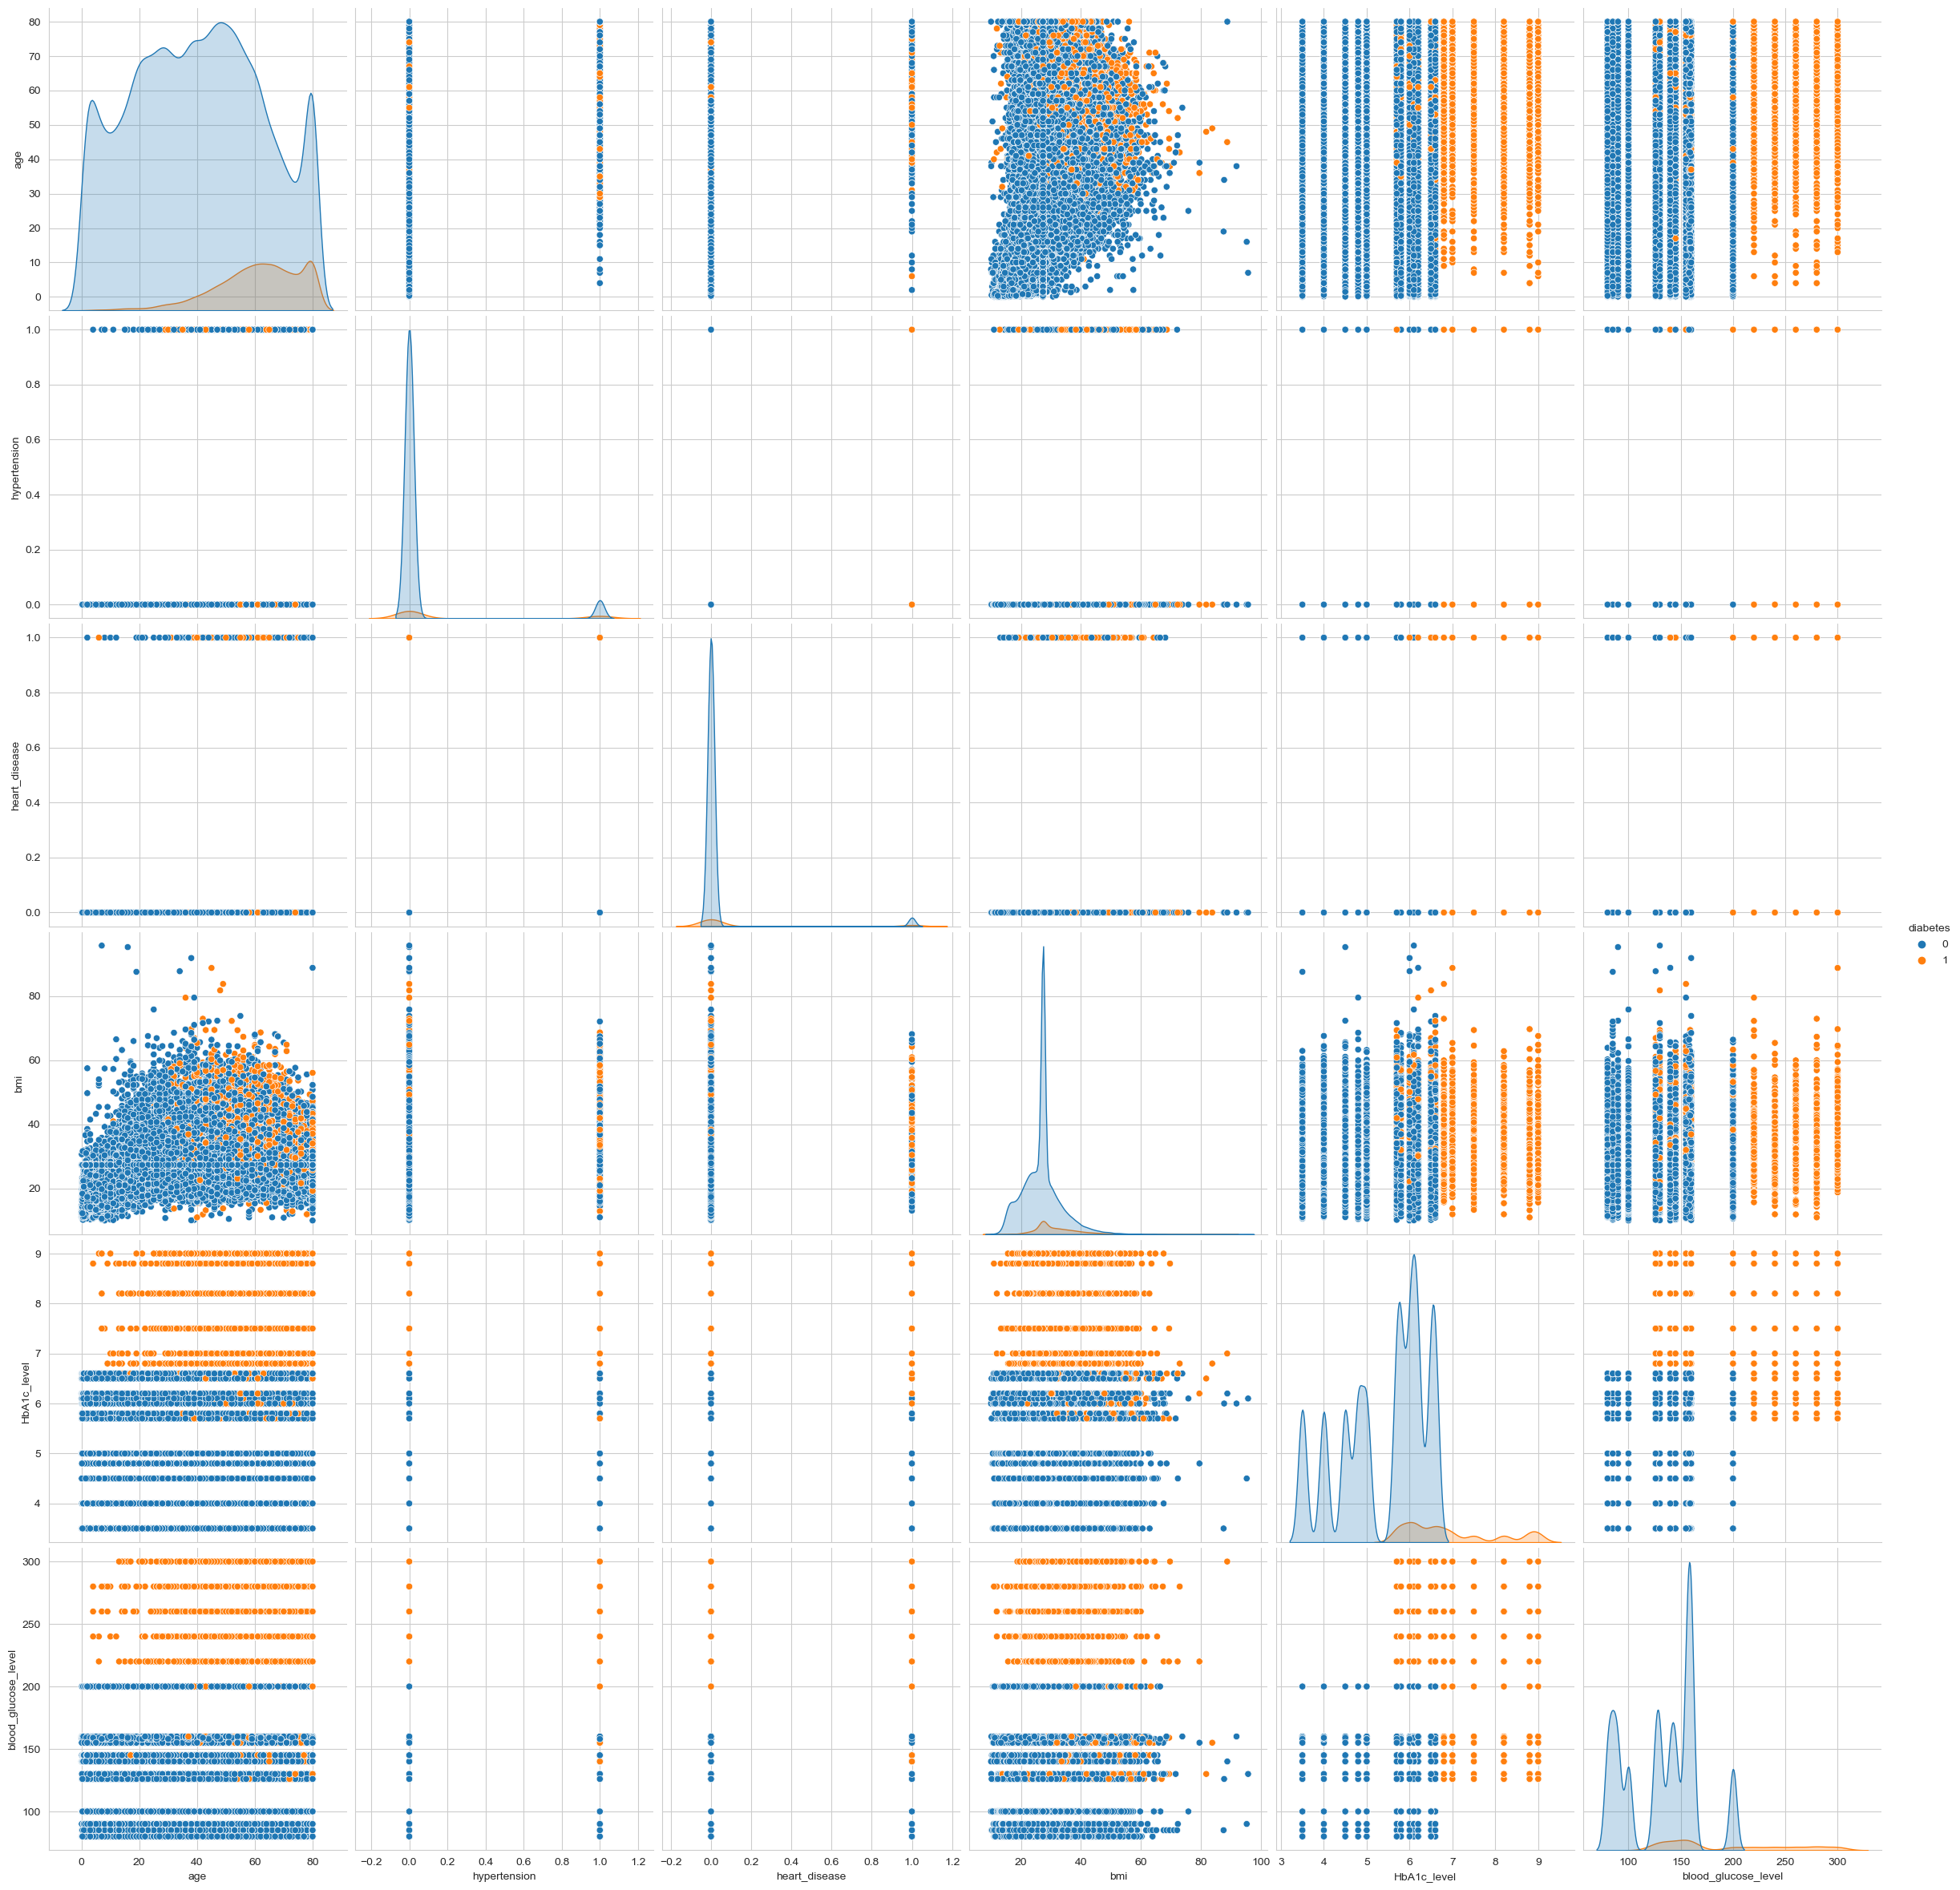

In [92]:
#pair plot
plt.close()
sns.set_style('whitegrid')
sns.pairplot(df,hue='diabetes',height=4)

plt.show()

# Observations: 
- We can say blood_glucose_level and H1Ac_level are most useful feature.

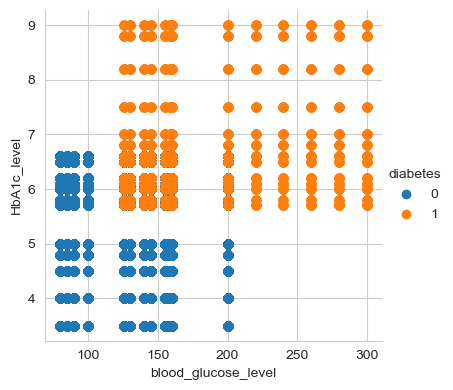

In [93]:
#2D scatter plot on blood_glucose_level and HbA1c_levek feature
sns.set_style('whitegrid')
sns.FacetGrid(df,hue='diabetes',height=4).map(plt.scatter,'blood_glucose_level','HbA1c_level').add_legend()
plt.show()

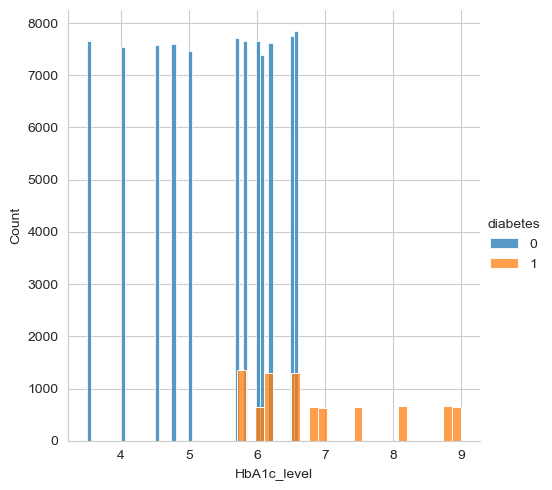

In [94]:
#Lets do 1D scatter plot
#1D scatter plot on 'HbA1C_level' feature
sns.FacetGrid(df,hue='diabetes',height=5).map(sns.histplot,'HbA1c_level').add_legend()
plt.show()

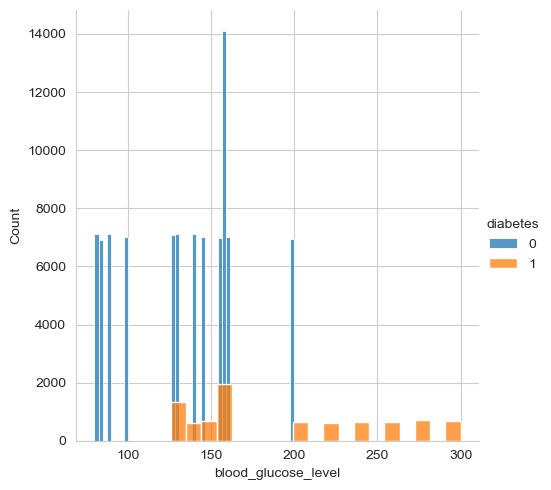

In [95]:
#1D scatter plot on 'blood_glucose_level' feature
sns.FacetGrid(df,hue='diabetes',height=5).map(sns.histplot,'blood_glucose_level').add_legend()
plt.show()

# Conclusion:
- We can build a simple model by using If-Else statement
- If Gender is other we can simply decleare no Diabetes else:
- If HbA1c_level <=6.7 and blood_glucose_level <=170 Then No Diabetes.
- Elif HbA1c_level <= 5.2 and blood_glucose_level >170  Then No Diabetes.
- Elif HbA1c_level > 6.7 and blood_glucose_level <= 170 then diabetes.
- Elif: HbA1c_level > 5.2 and blood_glucose_level >= 170 then diabetes.
- We will have some misclassification.
- Lets calculate error percentage.

In [96]:
#of all patient that have diabetes, in this thereshold 2478 classified as no diebetes.
#of all patients that have no diabetes, 84547 classified as no diabetes.
df[(df['HbA1c_level']<=6.7) & (df['blood_glucose_level'] <= 170) & (df['diabetes']==1)]


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
96,Female,67.0,0,0,never,27.32,6.2,159,1
242,Male,57.0,1,1,not current,27.77,6.6,160,1
253,Female,64.0,0,0,never,27.32,6.2,155,1
262,Male,80.0,0,0,never,23.25,6.1,159,1
350,Female,52.0,1,0,never,50.30,6.6,155,1
...,...,...,...,...,...,...,...,...,...
99652,Male,80.0,1,0,No Info,28.23,6.0,159,1
99723,Male,61.0,1,1,former,35.78,6.0,145,1
99829,Male,58.0,0,0,former,32.38,6.6,159,1
99845,Female,43.0,1,0,never,34.21,6.5,160,1


In [97]:
#of all patients who predicted as no diabetes, 0 of them have diabetes
df[(df['HbA1c_level']<=5.2) & (df['blood_glucose_level'] > 170) & (df['diabetes']==1)]


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [98]:
#of all patients that have no diabetes, 0 predicted as having diabetes.
df[(df['HbA1c_level']>6.7) & (df['blood_glucose_level'] <= 170)  & (df['diabetes']==0)]


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes


In [99]:
#of all patients that have no diabetes, 4099 are classified as having diabetes.
df[(df['HbA1c_level']>5.2) & (df['blood_glucose_level'] >= 170) & (df['diabetes']==0)]


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
13,Female,67.0,0,0,never,25.69,5.8,200,0
16,Male,15.0,0,0,never,30.36,6.1,200,0
37,Female,26.0,0,0,never,21.22,6.6,200,0
39,Female,34.0,0,0,never,56.43,6.2,200,0
65,Female,59.0,0,1,ever,23.11,6.5,200,0
...,...,...,...,...,...,...,...,...,...
99841,Female,9.0,0,0,No Info,14.13,6.5,200,0
99859,Female,56.0,0,0,never,26.70,6.2,200,0
99873,Female,29.0,0,0,never,21.71,6.6,200,0
99878,Female,21.0,0,0,never,17.56,6.2,200,0


# Conclusion:
- Here, patients who have diabetes, 29 % of time they predicted as having no diabetes.
- Patients who dont have diabetes, 4 % of time they predicted as having diabetes.